1. Introduction
This notebook loads and explores the raw EEG dataset (61 ADHD + 60 HC) used in the 2025 paper.

2. Dataset Overview
121 subjects (61 ADHD, 60 Healthy Control)
19 EEG channels, 128 Hz sampling rate
Visual attention task (cartoon number counting)

3. Loading .mat Files
Load raw .mat files from IEEE DataPort.

In [5]:
import scipy.io as sio
import numpy as np
import os

file_path = r"C:\Users\박지연\OneDrive\바탕 화면\EEG data for ADHD  Control children\ADHD_part1\v1p.mat"  

# 파일 불러오기
mat = sio.loadmat(file_path)

print("=== .mat 파일 안에 있는 키들 ===")
for key in mat.keys():
    if not key.startswith('__'):   # 숨겨진 변수 제외
        data_shape = np.shape(mat[key])
        print(f"키: {key:15} | shape: {data_shape} | 타입: {type(mat[key])}")

=== .mat 파일 안에 있는 키들 ===
키: v1p             | shape: (12258, 19) | 타입: <class 'numpy.ndarray'>


In [6]:
#2. .mat 파일 경로 설정 
data_dir = r'C:\Users\박지연\OneDrive\바탕 화면\EEG data for ADHD  Control children'   # 당신의 실제 폴더 경로로 변경!


# 테스트용으로 하나의 파일 불러오기 (ADHD 예시)
test_file = os.path.join(data_dir, 'ADHD_part1', 'v1p.mat')   # 실제 파일명으로 수정

if not os.path.exists(test_file):
    print("❌ 파일 경로를 확인해주세요. 파일이 존재하지 않습니다.")
else:
    # .mat 파일 로드
    mat = sio.loadmat(test_file)
    
    print("file load successed")
    print(f"파일 경로: {test_file}")
    print("\n=== 파일 안에 들어있는 주요 키 ===")
    
    for key in mat.keys():
        if not key.startswith('__'):
            shape = np.shape(mat[key])
            print(f"키: {key:20} | shape: {shape} | 타입: {type(mat[key])}")

file load successed
파일 경로: C:\Users\박지연\OneDrive\바탕 화면\EEG data for ADHD  Control children\ADHD_part1\v1p.mat

=== 파일 안에 들어있는 주요 키 ===
키: v1p                  | shape: (12258, 19) | 타입: <class 'numpy.ndarray'>


4. EEG Signal Extraction
Extract EEG data from 'v1p' key and check basic properties.
5. Channel Information
Define 19 channels according to 10-20 international system

In [7]:
# 3. EEG 데이터 추출

# .mat 파일에서 실제 EEG 신호 & 키 이름 가져오기
eeg_data = mat['v1p']        
sampling_rate = 128            # 논문에 명시된 sampling rate

print(f"EEG 데이터 shape: {eeg_data.shape}  → (시간 샘플 × 채널)")
print(f"총 기록 시간: {eeg_data.shape[0] / sampling_rate:.2f} 초")
print(f"채널 수: {eeg_data.shape[1]}")

# 채널 이름 정의 (논문과 IEEE DataPort 기준 19채널, 10-20 시스템)
channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz',
                 'C3', 'C4', 'Cz', 'T3', 'T4', 'T5', 'T6',
                 'P3', 'P4', 'Pz', 'O1', 'O2']

print("\n사용할 채널 목록:")
print(channel_names)

EEG 데이터 shape: (12258, 19)  → (시간 샘플 × 채널)
총 기록 시간: 95.77 초
채널 수: 19

사용할 채널 목록:
['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz', 'C3', 'C4', 'Cz', 'T3', 'T4', 'T5', 'T6', 'P3', 'P4', 'Pz', 'O1', 'O2']


6. Conversion to MNE RawArray
Convert data to MNE RawArray format for preprocessing.

In [10]:
# MNE RawArray 객체로 변환
import mne
from mne.io import RawArray
# 데이터 transpose: (channels, times) 형태로 변경 // MNE가 요구하는 형식
data_transposed = eeg_data.T   # shape: (19, 12258)

# 정보 객체 생성
info = mne.create_info(ch_names=channel_names, 
                       sfreq=sampling_rate, 
                       ch_types=['eeg'] * 19)

# RawArray 생성
raw = RawArray(data_transposed, info)

print("successed")
print(raw)
print(f"채널 수: {len(raw.ch_names)}")

Creating RawArray with float64 data, n_channels=19, n_times=12258
    Range : 0 ... 12257 =      0.000 ...    95.758 secs
Ready.
successed
<RawArray | 19 x 12258 (95.8 s), ~1.8 MiB, data loaded>
채널 수: 19


7. Data Visualization
Plot raw EEG signals and PSD.

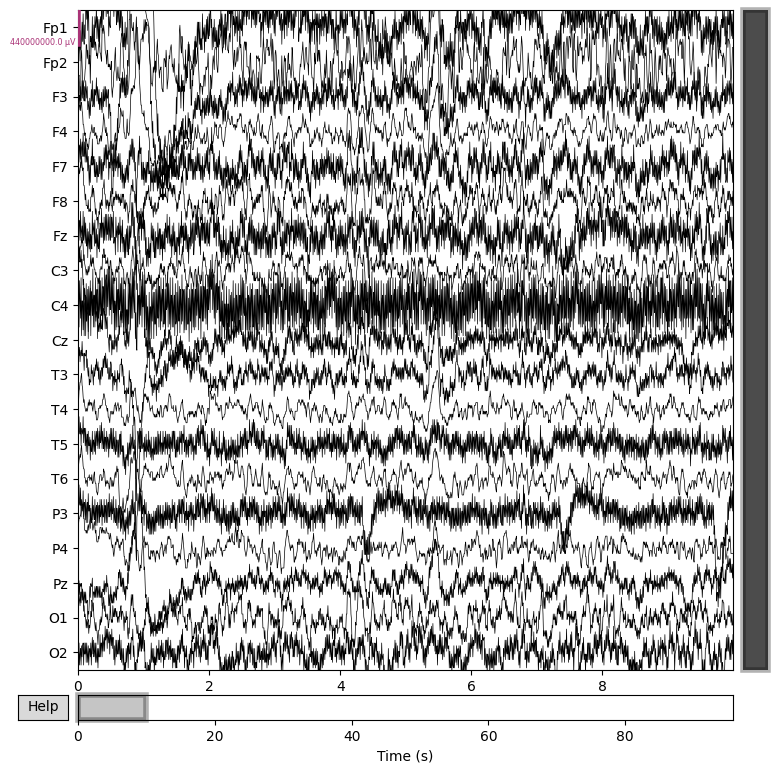

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\ProgramData\anaconda3\envs\eeg_adhd\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


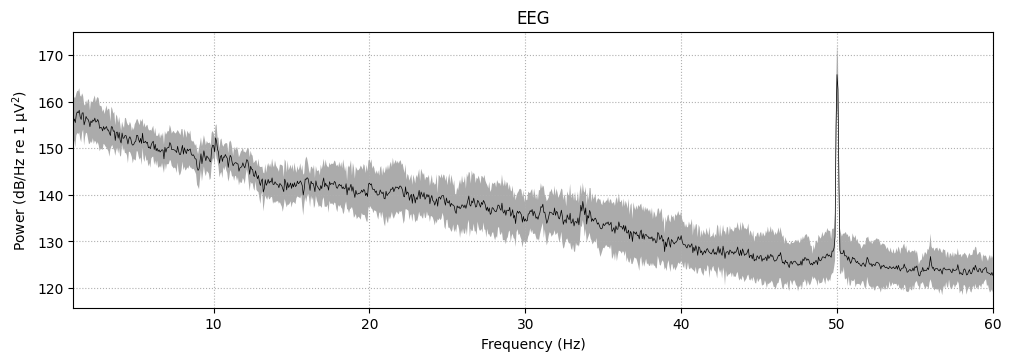

In [15]:
# 5. Raw 데이터 간단 시각화
import matplotlib.pyplot as plt

# 처음 10초만 plot // 너무 길면 느려지기 때문
raw.plot(duration=10, n_channels=19, scalings='auto', title='Raw EEG - First 10 seconds')
plt.show()

# Power Spectral Density (PSD) 확인
raw.plot_psd(fmin=1, fmax=60, average=True)
plt.show()

8. PSD Observation
Observed 1/f-like decay (power decreases with higher frequency). C4 channel showed highest power, possibly due to task-related activity or artifacts.
9. Summary & Next Steps
Data successfully loaded. Next: Band-pass filtering and ICA artifact removal.

In [17]:
raw.save('raw_eeg.fif', overwrite=True)
print("Raw data saved as raw_eeg.fif")

Writing C:\eeg_project\raw_eeg.fif
Closing C:\eeg_project\raw_eeg.fif
[done]
Raw data saved as raw_eeg.fif
